In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ASPBI Dataset

What we see that is most jobs in Region VII are from the Wholesale and retail trade sector.

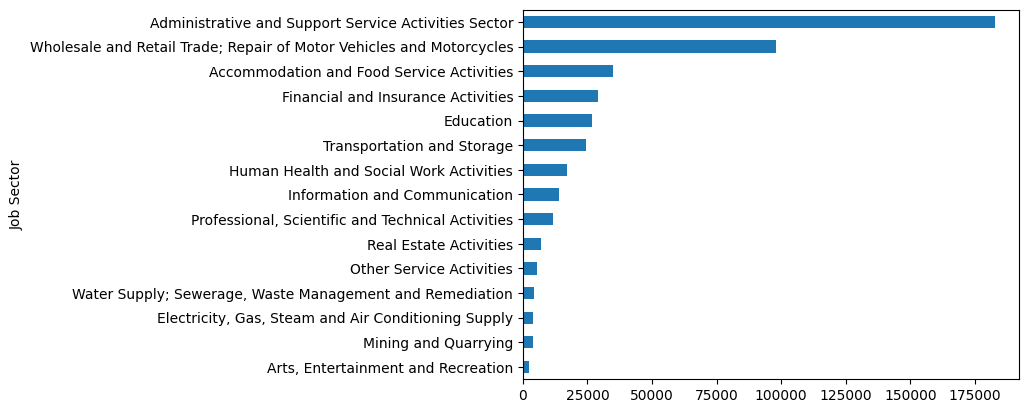

In [13]:
aggregated_df = pd.read_csv('../aspbi_data/aggregated_aspbi.csv')
aggregated_df['Total'] = pd.to_numeric(aggregated_df['Total'])
is_cebu = aggregated_df['Region Description'] == 'Region VII (Central Visayas)'
aggregated_df[is_cebu].groupby('Job Sector')['Total'].sum().sort_values(ascending=True).plot(kind='barh');

In [14]:
sectors = aggregated_df[is_cebu].groupby('Job Sector')['Total'].sum().sort_values(ascending=True)
sectors / sectors.sum()


Job Sector
Arts, Entertainment and Recreation                                      0.005139
Mining and Quarrying                                                    0.008390
Electricity, Gas, Steam and Air Conditioning Supply                     0.008743
Water Supply; Sewerage, Waste Management and Remediation                0.008820
Other Service Activities                                                0.011712
Real Estate Activities                                                  0.014686
Professional, Scientific and Technical Activities                       0.025384
Information and Communication                                           0.029941
Human Health and Social Work Activities                                 0.036657
Transportation and Storage                                              0.052076
Education                                                               0.057447
Financial and Insurance Activities                                      0.062683
Accommodation and

In [15]:
wholesale_2022 = 97914
wholesale_2021 = 95565
(wholesale_2022 - wholesale_2021) / wholesale_2021

0.02458012870820907

In [16]:
accomodation_2022 = 34928
accomodation_2021 = 32933

(accomodation_2022 - accomodation_2021) /accomodation_2021

0.06057753620988067

In [17]:
financial_2022 = 29174
financial_2021 = 24869
(financial_2022 - financial_2021) / financial_2021

0.17310708110499015

In [18]:
admin_2022 = 182863
admin_2021 =  188276 

(admin_2022 - admin_2021) / admin_2021

-0.028750345237842315

If we further check on the Administrative and Support Service Activities Sector, we see that it primarily focuses on call centers wit over 20% of all people in region VII working in just the Call centers and other related acitviites subsector.

<Axes: ylabel='Job Subsector'>

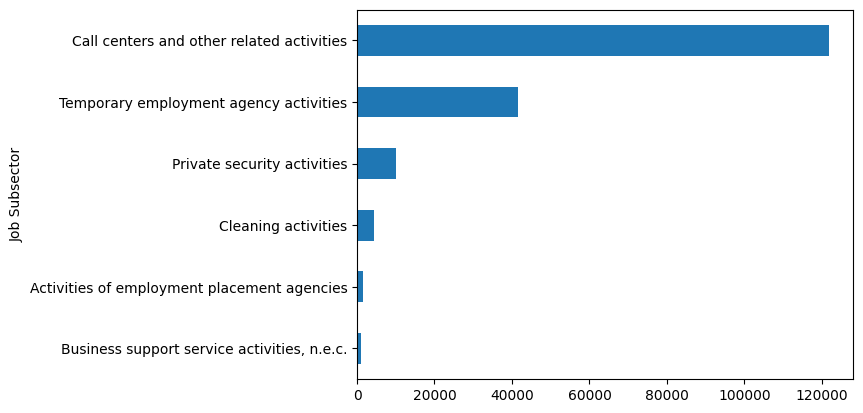

In [19]:
granular_df = pd.read_csv('../aspbi_data/granular_aspbi.csv')
is_cebu = granular_df['Region Description'] == 'Region VII (Central Visayas)'
is_admin = granular_df['Job Sector'] == 'Administrative and Support Service Activities Sector'
granular_df[is_cebu & is_admin].groupby('Job Subsector')[['Total Male', 'Total Female']].sum().sum(axis=1).sort_values(ascending=True).iloc[-6:].plot(kind='barh')

In [20]:
granular_df[is_cebu & is_admin].groupby('Job Subsector')[['Total Male', 'Total Female']].sum().sum(axis=1).sort_values(ascending=True)

Job Subsector
Security systems service activities                                                       0.0
Combined facilities support activities                                                    0.0
Investigation activities                                                                  0.0
Landscape care and maintenance service activities                                         0.0
Renting and leasing of motor vehicles                                                     0.0
Other human resources provision                                                           0.0
Renting and leasing of personal and household goods                                      52.0
Leasing of intellectual property and \nsimilar products, except copyrighted works       102.0
Other reservation service and related activities                                        125.0
Renting and leasing of other machinery, equipment and tangible goods, n.e.c.            253.0
Travel agency and tour operator activities    

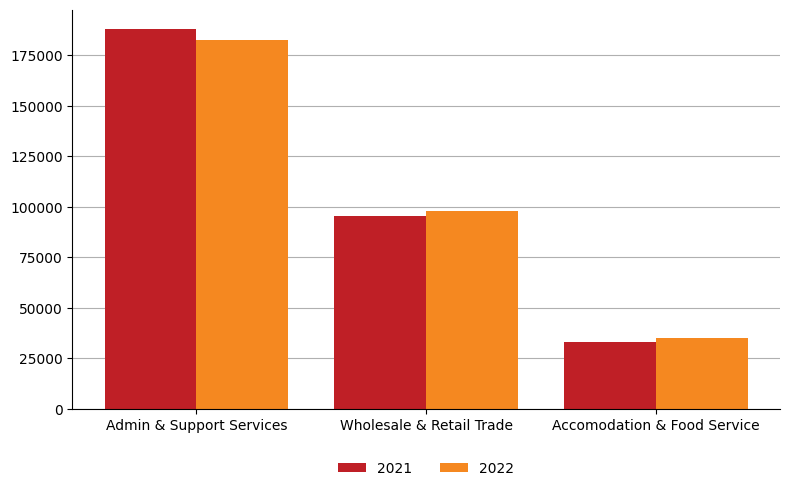

In [21]:
# Data
categories = ['Admin & Support Services', 'Wholesale & Retail Trade', 'Accomodation & Food Service']  # replace with actual names
year_2021 = [188276, 95565, 32933]
year_2022 = [182863, 97914, 34928]
growth = [-2.88, 2.46, 6.06]  # in %

x = range(len(categories))
bar_width = 0.4

fig, ax = plt.subplots(figsize=(8,5))

# Plot bars
ax.bar([i - bar_width/2 for i in x], year_2021, width=bar_width, label='2021', color='#bf1f26')
ax.bar([i + bar_width/2 for i in x], year_2022, width=bar_width, label='2022', color='#f58820ff')


ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel('Values')
ax.set_title('')
ax.legend()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.1),
    ncol=2,
    frameon=False
)

ax.set_axisbelow(True)
plt.grid(True, axis='y')

plt.ylabel('')
# show graph
plt.tight_layout()
plt.savefig("../figures/visayas_sectors.png", dpi=300, bbox_inches="tight")

# show graph
plt.show()


# Training Partners for Mid-Skills

Based on the data, the following TESDA courses should be prioritized:

- Contact Center Services NC II

To identify relevant schools, we searched for each NC II course and matched them with schools offering these programs. Since the data does not specify which course each student completed, we assume that all students graduated from a TESDA course. 


In [22]:
filepath = 'data/R7 TEDSA Schools_GGIS_ with graduate count and municipality codes.csv'
partners_df = pd.read_csv(filepath)

In [23]:
partners_df.loc[partners_df['TESDA Certificate'] == 'Contact Center Services NC II', 'Graduates'].sum()

7340

In [24]:
partners_df.loc[partners_df['TESDA Certificate'] == 'Contact Center Services NC II', ['Graduates', 'Provider Name']].sort_values(by='Graduates')

,Graduates,Provider Name
119,0,"ROSEMONT HILLS MONTESSORI COLLEGE, INC."
144,30,"INTELLISENSE INSTITUTE OF TECHNOLOGY, INC."
139,61,"NORTH COAST BOHOL INSTITUTE, INC."
128,70,SBR TECHNICAL EDUCATION TRAINING CENTER INC.
127,126,SAINT HOMOBONUS ACADEMY INC.
117,176,PRIMETECH SKILLS INSTITUTE INC.
118,330,"PRIMETECH SKILLS, INSTITUTE, INC."
122,533,PHILIPPINE CALL CENTER INSTITUTE INC.
72,594,THE FOUNDATION FOR PROFESSIONAL TRAINING INC. ...
86,1730,KM100 SKILLS AND TRAINING CENTER INC.


In [25]:
partners_df[partners_df['TESDA Certificate'] == 'Customer Service NC II']

,Provider Name,Graduates,Region,Province,Municipality,Municipality Code,lat,lon,TESDA Certificate,Source
3,TREETOPZ FARM ESCAPADE DIVERSIFIED FARM,132,Region VII - Central Visayas,Bohol,Alburquerque,PH0701201,9.610419,123.956884,Customer Service NC II,https://tesdaonlineprogram.com/list-of-tesda-a...
8,BALAMBAN COMMUNITY TRAINING CENTER,36,Region VII - Central Visayas,Cebu,Balamban,PH0702208,10.504892,123.714823,Customer Service NC II,https://tesdaonlineprogram.com/list-of-tesda-a...
17,Provincial Training Center - Cebu (Carmen),334,Region VII - Central Visayas,Cebu,Carmen,PH0702215,10.608560,123.968361,Customer Service NC II,https://tesdaonlineprogram.com/list-of-tesda-a...
19,3A PRIME HOSPITALITY TRAINING AND ASSESSMENT C...,2009,Region VII - Central Visayas,Cebu,Cebu City (Capital),PH0702217,10.296323,123.898304,Customer Service NC II,https://tesdaonlineprogram.com/list-of-tesda-a...


In [26]:
partners_df[partners_df['TESDA Certificate'] == 'Contact Center Services NC II']

,Provider Name,Graduates,Region,Province,Municipality,Municipality Code,lat,lon,TESDA Certificate,Source
35,CEBU CALL CENTER ACADEMY,3690,Region VII - Central Visayas,Cebu,Cebu City (Capital),PH0702217,10.316720,123.890710,Contact Center Services NC II,https://www.tesda.gov.ph/Tvi/sch?sch=1744
72,THE FOUNDATION FOR PROFESSIONAL TRAINING INC. ...,594,Region VII - Central Visayas,Cebu,Cebu City (Capital),PH0702217,10.316720,123.890710,Contact Center Services NC II,https://www.tesda.gov.ph/Tvi/Result?page=4&cur...
86,KM100 SKILLS AND TRAINING CENTER INC.,1730,Region VII - Central Visayas,Cebu,City of Bogo,PH0702211,11.048859,123.991428,Contact Center Services NC II,https://www.tesda.gov.ph/Tvi/sch?sch=1849
117,PRIMETECH SKILLS INSTITUTE INC.,176,Region VII - Central Visayas,Cebu,Danao City,PH0702223,10.525295,123.999828,Contact Center Services NC II,https://www.tesda.gov.ph/Tvi/sch?sch=1821
118,"PRIMETECH SKILLS, INSTITUTE, INC.",330,Region VII - Central Visayas,Cebu,Danao City,PH0702223,10.540060,123.940340,Contact Center Services NC II,https://www.tesda.gov.ph/Tvi/sch?sch=1821
119,"ROSEMONT HILLS MONTESSORI COLLEGE, INC.",0,Region VII - Central Visayas,Cebu,Danao City,PH0702223,10.540060,123.940340,Contact Center Services NC II,https://www.tesda.gov.ph/Tvi/sch?sch=1829
122,PHILIPPINE CALL CENTER INSTITUTE INC.,533,Region VII - Central Visayas,Bohol,Tagbilaran City,PH0701242,9.655560,123.852190,Contact Center Services NC II,https://www.tesda.gov.ph/Tvi/sch?sch=1689
127,SAINT HOMOBONUS ACADEMY INC.,126,Region VII - Central Visayas,Cebu,Lapu-Lapu City (Opon),PH0702226,10.310280,123.949440,Contact Center Services NC II,https://www.tesda.gov.ph/Tvi/sch?sch=1856
128,SBR TECHNICAL EDUCATION TRAINING CENTER INC.,70,Region VII - Central Visayas,Bohol,Tagbilaran City,PH0701242,9.655560,123.852190,Contact Center Services NC II,https://www.tesda.gov.ph/Tvi/sch?sch=1696
139,"NORTH COAST BOHOL INSTITUTE, INC.",61,Region VII - Central Visayas,Bohol,Talibon,PH0701243,10.150801,124.326924,Contact Center Services NC II,https://www.tesda.gov.ph/Tvi/Result?page=5&cur...


In [27]:
partners_df['Graduates'].median()

68.5

In [28]:
partners_df['Graduates'].sum()

36693

In [ ]:
"""
<tbody>
<tr>
<th style="text-align: center;" scope="col"><strong>TAXONOMY</strong></th>
<th style="text-align: center;" scope="col"><strong>MUNICIPALITY</strong></th>
<th style="text-align: center;" scope="col"><strong>SCHOOL ID</strong></th>
<th style="text-align: center;" scope="col">SCHOOL NAME</th>
<th style="text-align: center;" scope="col"><strong>PROGRAM OFFERINGS</strong></th>
</tr>
<tr>
<td width="83">Region VII|Bohol</td>
<td width="75">Anda</td>
<td width="64">404233</td>
<td width="172">Holy Infant Academy-Anda</td>
<td width="154">GAS</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Antequera</td>
<td>404234</td>
<td>Christ the King Academy</td>
<td>ABM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Baclayon</td>
<td>404235</td>
<td>Immaculata High School</td>
<td>GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Balilihan</td>
<td>407537</td>
<td>Carmel Academy</td>
<td>ABM|STEM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Balilihan</td>
<td>600253</td>
<td>Bohol Island State University-Balilihan Campus</td>
<td>TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Batuan</td>
<td>403511</td>
<td>Saint Anthony Academy</td>
<td>GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Batuan</td>
<td>405890</td>
<td>Batuan Colleges, Inc.</td>
<td>ABM|STEM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Bien Unido</td>
<td>404295</td>
<td>Bien Unido Academy</td>
<td>GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Bien Unido</td>
<td>404296</td>
<td>Holy Child Academy</td>
<td>GAS</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Bilar</td>
<td>446533</td>
<td>Immaculate Mother School of Bilar, Inc.</td>
<td>GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Bilar</td>
<td>600070</td>
<td>Bohol Island State University-Bilar Campus</td>
<td>TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Buenavista</td>
<td>403250</td>
<td>Buenavista Community College</td>
<td>HUMSS|GAS|STEM|ABM|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Cadiz City</td>
<td>406292</td>
<td>Artiaga's Learning Center Inc.</td>
<td>GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Calape</td>
<td>600254</td>
<td>Bohol Island State University-Calape Campus</td>
<td>TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Candijay</td>
<td>404239</td>
<td>St. Joseph Academy</td>
<td>ABM|HUMSS|GAS</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Candijay</td>
<td>600071</td>
<td>Bohol Island State University-Candijay Campus</td>
<td>TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Carmen</td>
<td>407535</td>
<td>BIT International College-Carmen</td>
<td>GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Catigbian</td>
<td>404241</td>
<td>Holy Infant Academy-Catigbian</td>
<td>GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Catigbian</td>
<td>404242</td>
<td>Immaculate Mary Academy</td>
<td>GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Catigbian</td>
<td>405889</td>
<td>Bohol Northwestern Colleges</td>
<td>ABM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Clarin</td>
<td>446542</td>
<td>Presentation of Mary School of Clarin, Inc.</td>
<td>GAS|HUMSS</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Clarin</td>
<td>600255</td>
<td>Bohol Island State University-Clarin Campus</td>
<td>TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Cortes</td>
<td>404243</td>
<td>Infant King Academy</td>
<td>GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Cortes</td>
<td>446510</td>
<td>Bohol International Learning Center</td>
<td>HUMSS|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Dauis</td>
<td>446544</td>
<td>International Academe of Ensciema</td>
<td>GAS|HUMSS|STEM</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Dauis</td>
<td>(Blank)</td>
<td>STI College Bohol, Inc.</td>
<td>ABM|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Dimiao</td>
<td>404244</td>
<td>Saint Nicholas Academy</td>
<td>GAS</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Duero</td>
<td>404245</td>
<td>Immaculate Academy</td>
<td>GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Garcia-Hernandez</td>
<td>404246</td>
<td>St. John the Baptist Academy</td>
<td>GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Getafe</td>
<td>404253</td>
<td>Santo Niño Institute</td>
<td>ABM|GAS</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Guindulman</td>
<td>404247</td>
<td>Saint Mary Academy</td>
<td>GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Inabanga</td>
<td>403270</td>
<td>Saint Paul's Academy</td>
<td>ABM|GAS</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Jagna</td>
<td>404249</td>
<td>BIT International College-Jagna</td>
<td>GAS|ABM|HUMSS|STEM|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Jagna</td>
<td>404250</td>
<td>Central Visayan Institute Foundation</td>
<td>STEM|ABM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Jagna</td>
<td>404251</td>
<td>Colegio dela Medalla Milagrosa</td>
<td>STEM|GAS</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Jagna</td>
<td>404252</td>
<td>San Miguel Academy, Bohol</td>
<td>GAS</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Kapawan</td>
<td>404282</td>
<td>Blessed Trinity College - A.R. of Talibon, Bohol, Inc.</td>
<td>GAS|ABM|STEM|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Lila</td>
<td>407539</td>
<td>Holy Rosary Academy</td>
<td>GAS</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Loay</td>
<td>407540</td>
<td>Holy Trinity Academy</td>
<td>GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Loboc</td>
<td>404256</td>
<td>PMI-Loboc Academy</td>
<td>GAS</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Loon</td>
<td>404258</td>
<td>Saint Teresa Academy</td>
<td>GAS</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Loon</td>
<td>404259</td>
<td>UB-Loon Institute</td>
<td>ABM|GAS|HUMSS|STEM</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Loon</td>
<td>405738</td>
<td>Bohol College of Science and Technology, Inc.-Loon Campus</td>
<td>TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Loon</td>
<td>407541</td>
<td>Sacred Heart Academy</td>
<td>GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Mabini</td>
<td>404260</td>
<td>Santa Monica Institute</td>
<td>GAS</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Maribojoc</td>
<td>404262</td>
<td>Saint Vincent Institute</td>
<td>GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>North Carmen</td>
<td>404240</td>
<td>St. Anthony's Academy</td>
<td>ABM|GAS</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Panglao</td>
<td>403266</td>
<td>Cristal e-College</td>
<td>ABM|STEM|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Panglao</td>
<td>404263</td>
<td>San Agustin Academy</td>
<td>GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Panglao</td>
<td>446505</td>
<td>Arbasto Foundation, Inc.</td>
<td>TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Panglao</td>
<td>446627</td>
<td>Panglao Christian Academy, Inc.</td>
<td>GAS</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Pilar</td>
<td>404264</td>
<td>Virgen del Pilar Academy</td>
<td>GAS</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Pilar</td>
<td>600308</td>
<td>Bohol College of Science and Technology, Inc.-Pilar Campus</td>
<td>TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>President Carlos P. Garcia (Pitogo)</td>
<td>407538</td>
<td>Holy Child Academy of Pitogo, Bohol, Inc.</td>
<td>GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Sagbayan</td>
<td>600307</td>
<td>Bohol College of Science and Technology, Inc.-Main Campus</td>
<td>TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Sagbayan (Borja)</td>
<td>404267</td>
<td>St. Augustine Institute of Sagbayan, Bohol Inc.</td>
<td>HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Tagbilaran City (Capital)</td>
<td>403554</td>
<td>STI College - Bohol</td>
<td>GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Tagbilaran City (Capital)</td>
<td>404269</td>
<td>BIT International College-Tagbilaran</td>
<td>STEM|ABM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Tagbilaran City (Capital)</td>
<td>404270</td>
<td>Bohol Wisdom School</td>
<td>STEM|ABM|HUMSS</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Tagbilaran City (Capital)</td>
<td>404272</td>
<td>Tagbilaran Grace Christian School</td>
<td>ABM|STEM|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Tagbilaran City (Capital)</td>
<td>404273</td>
<td>Holy Name University</td>
<td>STEM|ABM|HUMSS|GAS|Sports|Arts and Design</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Tagbilaran City (Capital)</td>
<td>404274</td>
<td>Holy Spirit School of Tagbilaran</td>
<td>STEM|ABM|GAS</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Tagbilaran City (Capital)</td>
<td>404277</td>
<td>Royal Christian School</td>
<td>HUMSS</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Tagbilaran City (Capital)</td>
<td>404280</td>
<td>University of Bohol</td>
<td>GAS</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Tagbilaran City (Capital)</td>
<td>404281</td>
<td>Victoriano D. Tirol Advanced Learning Center</td>
<td>STEM|ABM|HUMSS|GAS|Sports|Arts and Design|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Tagbilaran City (Capital)</td>
<td>492001</td>
<td>Holy Infant School of Tagbilaran</td>
<td>GAS|Sports|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Tagbilaran City (Capital)</td>
<td>492010</td>
<td>Immaculate Heart of Mary Seminary</td>
<td>HUMSS|GAS</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Tagbilaran City (Capital)</td>
<td>492018</td>
<td>Schola Societas, Inc.</td>
<td>GAS</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Tagbilaran City (Capital)</td>
<td>600022</td>
<td>Bohol Island State University-Main Campus</td>
<td>TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Tagbilaran City (Capital)</td>
<td>(Blank)</td>
<td>Cristal e-College</td>
<td>TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Talibon</td>
<td>404284</td>
<td>Bohol Maranatha Christian Academy, Inc.</td>
<td>GAS</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Talibon</td>
<td>407536</td>
<td>BIT International College-Talibon</td>
<td>HUMSS|ABM|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Trinidad</td>
<td>404285</td>
<td>St. Isidore Academy of Trinidad</td>
<td>ABM|GAS</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Tubigon</td>
<td>404286</td>
<td>Holy Cross Academy</td>
<td>STEM|GAS|HUMSS|ABM|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Tubigon</td>
<td>404287</td>
<td>Holy Family of Nazareth School</td>
<td>STEM|ABM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Tubigon</td>
<td>404288</td>
<td>Salus Institute of Technology</td>
<td>GAS</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Tubigon</td>
<td>446511</td>
<td>Mater Dei College</td>
<td>ABM|HUMSS|GAS|STEM|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Tubigon</td>
<td>(Blank)</td>
<td>St. Pedro Calungsod College, Inc.</td>
<td>GAS|ABM|HUMSS|STEM|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Ubay</td>
<td>404289</td>
<td>Bohol Northeastern Education Foundation, Inc.</td>
<td>HUMSS|ABM|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Ubay</td>
<td>404291</td>
<td>Holy Child Academy (Ubay)</td>
<td>ABM|GAS</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Ubay</td>
<td>404293</td>
<td>San Pascual Academy</td>
<td>GAS</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Ubay</td>
<td>405892</td>
<td>Montessori Educational Learning Center of Ubay, Inc.</td>
<td>GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Bohol</td>
<td>Ubay</td>
<td>446513</td>
<td>Icthus Christian Academy, Inc.</td>
<td>STEM|GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Alcantara</td>
<td>404297</td>
<td>Saint Augustine Academy, Inc.</td>
<td>ABM|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Alegria</td>
<td>404298</td>
<td>Saint Peter Academy of Alegria, Inc.</td>
<td>GAS|ABM|STEM|HUMSS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Argao</td>
<td>447042</td>
<td>Saint Michael School</td>
<td>GAS|HUMSS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Argao</td>
<td>447062</td>
<td>Argao Center for Science Learning, Inc.</td>
<td>GAS|HUMSS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Argao</td>
<td>600256</td>
<td>Cebu Technological University-Argao Campus</td>
<td>TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Asturias</td>
<td>447104</td>
<td>Isler Superior High, Inc.</td>
<td>TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Badian</td>
<td>404301</td>
<td>Saint James Academy</td>
<td>GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Balamban</td>
<td>404303</td>
<td>St. Francis Academy</td>
<td>GAS|STEM|ABM|HUMSS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Balamban</td>
<td>447054</td>
<td>Little Angels Montessori School of Cebu Inc.</td>
<td>ABM|GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Balamban</td>
<td>447087</td>
<td>University of San Jose-Recoletos Balamban Campus</td>
<td>ABM|STEM|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Bantayan</td>
<td>403292</td>
<td>Saint Paul Academy Inc.</td>
<td>STEM|ABM|HUMSS|GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Bantayan</td>
<td>404305</td>
<td>Bantayan Southern Institute</td>
<td>ABM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Barili</td>
<td>404313</td>
<td>Sta. Ana Academy of Barili, Inc.</td>
<td>HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Barili</td>
<td>406554</td>
<td>Santa Anna Academy of Barili, Inc.</td>
<td>GAS|HUMSS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Barili</td>
<td>600257</td>
<td>Cebu Technological University-Barili</td>
<td>TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Boljoon</td>
<td>447075</td>
<td>Patronage of Mary Development School</td>
<td>GAS|ABM|STEM|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Borbon</td>
<td>404319</td>
<td>Don Emilio Osmeña Memorial School</td>
<td>GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Carmen</td>
<td>404327</td>
<td>Cebu Academy</td>
<td>GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Carmen</td>
<td>407661</td>
<td>St. Joseph's Academy, Carmen, Cebu, Inc.</td>
<td>GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Carmen</td>
<td>600258</td>
<td>Cebu Technological University-Carmen Campus</td>
<td>STEM|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Catmon</td>
<td>404328</td>
<td>Gabriel Jurado Foundation School, Inc.</td>
<td>STEM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Catmon</td>
<td>404329</td>
<td>Passionist Sister's School (Catmon), Inc.</td>
<td>HUMSS|GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Catmon</td>
<td>447099</td>
<td>Saint William Cooperative School</td>
<td>ABM|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>403297</td>
<td>AMA Computer College, Inc.-Cebu City</td>
<td>ABM|STEM|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>403314</td>
<td>Blessed John XXIII Seminary</td>
<td>GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>403319</td>
<td>CBD Institute of Learning, Inc</td>
<td>STEM|ABM|GAS|HUMSS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>403323</td>
<td>College of Technological Sciences</td>
<td>ABM|STEM|GAS|HUMSS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>403330</td>
<td>Informatics College Cebu, Inc.</td>
<td>ABM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>403336</td>
<td>International School for Culinary Arts and Hotel Mgt.-Cebu</td>
<td>TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>403341</td>
<td>Rizwoods Colleges-Sambag</td>
<td>STEM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>403342</td>
<td>Rogationist Seminary College - Cebu</td>
<td>HUMSS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>403349</td>
<td>STI College - Cebu</td>
<td>ABM|STEM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>403351</td>
<td>University of Cebu - Banilad Branch</td>
<td>STEM|ABM|HUMSS|GAS|Arts and Design|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>403355</td>
<td>University of Cebu - Main Campus</td>
<td>STEM|ABM|HUMSS|GAS|Arts and Design|Sports|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>403365</td>
<td>University of Cebu - METC Branch</td>
<td>STEM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404026</td>
<td>Colegio de la Inmaculada Concepcion</td>
<td>ABM|STEM|GAS|Arts and Design|HUMSS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404364</td>
<td>St. Paul School of Medellin, Inc.</td>
<td>ABM|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404419</td>
<td>Lyceum of Cebu</td>
<td>STEM|ABM|HUMSS|GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404423</td>
<td>Cebu Bradford School</td>
<td>STEM|ABM|GAS|HUMSS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404424</td>
<td>Cebu Cherish School, Inc.</td>
<td>ABM|GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404428</td>
<td>Cebu International Distance Education College</td>
<td>ABM|HUMSS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404432</td>
<td>Centre for International Education Global Colleges</td>
<td>ABM</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404441</td>
<td>Harvest Christian School International of Cebu, Inc.</td>
<td>ABM|GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404443</td>
<td>Living Word Christian Learning Center of Cebu, Inc.</td>
<td>ABM|STEM|GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404444</td>
<td>Mabolo Christian Academy</td>
<td>GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404447</td>
<td>Marie Ernestine School</td>
<td>ABM|STEM|GAS|HUMSS|Arts and Design|Sports|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404449</td>
<td>Matilda L. Bradford Christian School, Inc.</td>
<td>STEM|ABM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404452</td>
<td>PAREF Southcrest School, Inc.</td>
<td>ABM|HUMSS|GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404453</td>
<td>PAREF Springdale School, Inc.</td>
<td>GAS|STEM|ABM</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404454</td>
<td>Philippine Christian Gospel School</td>
<td>ABM|STEM</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404456</td>
<td>Pope John XXIII Seminary School</td>
<td>GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404458</td>
<td>Sacred Heart-Hijas de Jesus</td>
<td>ABM|STEM</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404459</td>
<td>Samantabhadra Educational Institute, Inc.</td>
<td>ABM</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404460</td>
<td>San Isidro Parish School</td>
<td>ABM|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404462</td>
<td>Southwestern University</td>
<td>ABM|HUMSS|STEM|GAS|Sports|Arts and Design|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404465</td>
<td>St. Theresa's College-Cebu</td>
<td>ABM|GAS|STEM|HUMSS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404472</td>
<td>University of San Carlos Basic Education Deparment - North Campus</td>
<td>STEM</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404474</td>
<td>University of Southern Philippines Foundation-Mabini</td>
<td>STEM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404475</td>
<td>University of Southern Philippines Foundation-Lahug</td>
<td>ABM|STEM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404476</td>
<td>University of the Visayas-Main Campus</td>
<td>STEM|HUMSS|ABM|GAS|Arts and Design|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404477</td>
<td>Visayan Nazarene Bible College</td>
<td>GAS|HUMSS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404478</td>
<td>Woodridge International School</td>
<td>ABM</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404480</td>
<td>Bethany Christian School</td>
<td>ABM|STEM</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404482</td>
<td>Bob Hughes Christian Academy</td>
<td>ABM|HUMSS|GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404483</td>
<td>CBD College</td>
<td>STEM|ABM|HUMSS|GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404485</td>
<td>Cebu Eastern College</td>
<td>ABM|HUMSS|STEM|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404486</td>
<td>Cebu Institute of Technology University</td>
<td>ABM|STEM|GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404488</td>
<td>Child Learning Foundation Inc.</td>
<td>ABM|STEM|HUMSS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404489</td>
<td>Childlink Learning Center and Childlink High School Inc</td>
<td>STEM</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404491</td>
<td>Evangelical Theological College of the Philippines, Inc.</td>
<td>GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404492</td>
<td>Concord Technical Institute, Inc.</td>
<td>GAS|ABM|HUMSS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404493</td>
<td>Don Bosco Technology Center, Inc.</td>
<td>STEM|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404495</td>
<td>Holy Rosary School of Pardo</td>
<td>ABM|HUMSS|STEM|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404500</td>
<td>Marianne Childhood Education Center</td>
<td>STEM|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404501</td>
<td>M-Zed Christian School</td>
<td>ABM|GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404507</td>
<td>Royal Oaks International School-Cebu City</td>
<td>ABM|HUMSS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404508</td>
<td>SAE Young Christian School</td>
<td>STEM|GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404511</td>
<td>St. Francis of Assissi School</td>
<td>GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404513</td>
<td>St. Mary's Academy of San Nicolas</td>
<td>ABM|STEM|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404514</td>
<td>St. Paul College Foundation, Inc.</td>
<td>GAS|HUMSS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404515</td>
<td>St. Paul Learning Center, Inc.</td>
<td>STEM|ABM</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>404516</td>
<td>University of San Jose-Recoletos</td>
<td>ABM|STEM|GAS|HUMSS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>405739</td>
<td>Asian Institute of Computer Studies - Cebu</td>
<td>ABM|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>405740</td>
<td>Britech College</td>
<td>GAS|ABM|HUMSS|Sports|Arts and Design|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>405742</td>
<td>School of Knowledge for Industrial Labor, Leadership and Service (SKILLS)</td>
<td>ABM|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>406299</td>
<td>International Institute of Technology and Management-Cebu, Inc.</td>
<td>ABM|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>406310</td>
<td>ISHRM School-Cebu</td>
<td>TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>406568</td>
<td>Banilad Center for Professional Development</td>
<td>TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>406579</td>
<td>CITE Technical Institute</td>
<td>ABM|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>406709</td>
<td>FBC Christian School</td>
<td>ABM</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>406848</td>
<td>Datamex Institute of Computer Technology-Cebu City</td>
<td>GAS|STEM|HUMSS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>407546</td>
<td>University of San Carlos - Basic Education Department South Campus</td>
<td>ABM|HUMSS|Sports|Arts and Design</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>407547</td>
<td>University of the Visayas-Pardo Campus</td>
<td>STEM|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>407663</td>
<td>Salazar Colleges of Science and Institute of Technology-Main Campus</td>
<td>ABM|GAS|STEM|HUMSS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>447145</td>
<td>Mary Our Help Technical Institute for Women, Inc.</td>
<td>ABM|STEM| TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>447510</td>
<td>Cebu Mary Immaculate College - Talamban</td>
<td>ABM|STEM|GAS|Arts and Design|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>447511</td>
<td>Maria Montessori International School</td>
<td>GAS|STEM|ABM|HUMSS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>447512</td>
<td>B.R.I.G.H.T. Academy</td>
<td>ABM|STEM|HUMSS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>447527</td>
<td>Maranatha Christian Academy, Inc. of Cebu</td>
<td>GAS|ABM</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>447534</td>
<td>Golden Success College, Inc.</td>
<td>HUMSS|ABM|STEM|Arts and Design|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>447550</td>
<td>Asian College of Technology-International Education Foundation-AIS-Cebu City</td>
<td>STEM|ABM|HUMSS|GAS|Arts and Design|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>447552</td>
<td>Saint Paul College Foundation, Inc.- Ramos Campus</td>
<td>GAS|HUMSS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>447562</td>
<td>Saint Anthony Montessori Learning Center, Inc</td>
<td>ABM|HUMSS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>447564</td>
<td>Three H Redwood Academy, Inc.</td>
<td>ABM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>600263</td>
<td>Cebu Technological University-Main</td>
<td>ABM|STEM|HUMSS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cebu City (Capital)</td>
<td>600332</td>
<td>University of the Philippines High School - Cebu</td>
<td>STEM|HUMSS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>City of Bogo</td>
<td>404315</td>
<td>Cebu Roosevelt Memorial Colleges</td>
<td>ABM|STEM|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>City of Bogo</td>
<td>404316</td>
<td>Felipe R. Verallo Memorial Foundation College</td>
<td>ABM|STEM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>City of Bogo</td>
<td>404317</td>
<td>Northern Cebu Colleges</td>
<td>HUMSS|GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>City of Bogo</td>
<td>404318</td>
<td>St. Louise de Marillac College of Bogo</td>
<td>ABM|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>City of Bogo</td>
<td>447030</td>
<td>San Roque Child Development Center - Bogo Campus</td>
<td>STEM|ABM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>City of Bogo</td>
<td>(Blank)</td>
<td>Araneta Learning Center for Child Development, Inc.</td>
<td>GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>City of Carcar</td>
<td>404320</td>
<td>Carcar Academy Technical School Inc.</td>
<td>STEM|ABM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>City of Carcar</td>
<td>404323</td>
<td>Mother Mary's Children School</td>
<td>STEM|ABM</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>City of Carcar</td>
<td>404324</td>
<td>St. Catherine's College</td>
<td>STEM|ABM|HUMSS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>City of Carcar</td>
<td>406549</td>
<td>Datamex Institute of Computer Technology-Carcar City</td>
<td>GAS|STEM|HUMSS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>City of Carcar</td>
<td>407677</td>
<td>Carcar City College</td>
<td>TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>City of Carcar</td>
<td>447011</td>
<td>St. Elijah Christian Institute of Technology Foundation, Inc.</td>
<td>ABM|HUMSS|GAS|STEM</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>City of Carcar</td>
<td>447021</td>
<td>Cebu Sacred Heart College, Inc. - Carcar Campus</td>
<td>GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>City of Carcar</td>
<td>447089</td>
<td>St. Teresa's School of Valladolid</td>
<td>HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>City of Carcar</td>
<td>447090</td>
<td>Eastside Christian Academy</td>
<td>ABM|STEM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>City of Naga</td>
<td>403445</td>
<td>Professional Academy of the Philippines</td>
<td>GAS|HUMSS|ABM|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>City of Naga</td>
<td>403449</td>
<td>Academia de San Pedro Calungsod</td>
<td>ABM|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>City of Naga</td>
<td>447014</td>
<td>Exceed Learning Center Naga, Cebu Inc.</td>
<td>STEM|HUMSS|GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>City of Naga</td>
<td>447035</td>
<td>Bethel Christian Living Heritage School</td>
<td>ABM|HUMSS|STEM|GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>City of Talisay</td>
<td>403555</td>
<td>Saint Scholastica's Academy</td>
<td>STEM|ABM|GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>City of Talisay</td>
<td>404394</td>
<td>Cherubs Academy, Inc.</td>
<td>GAS|HUMSS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>City of Talisay</td>
<td>404395</td>
<td>Divino Amore Academy</td>
<td>GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>City of Talisay</td>
<td>404402</td>
<td>Monterey School Inc.</td>
<td>ABM|Arts and Design</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>City of Talisay</td>
<td>404403</td>
<td>Cebu Sacred Heart College Inc.</td>
<td>ABM|GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>City of Talisay</td>
<td>404409</td>
<td>Saint Teresa's School</td>
<td>ABM|GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>City of Talisay</td>
<td>404410</td>
<td>St. Thomas Aquinas School Of Lawa-An (Montessori) Inc.</td>
<td>STEM|ABM|HUMSS|GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>City of Talisay</td>
<td>404414</td>
<td>Talisay Malayan Academy</td>
<td>GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>City of Talisay</td>
<td>406587</td>
<td>ABQ International Health Caregiver Program and Consultancy Incorporation</td>
<td>TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>City of Talisay</td>
<td>406710</td>
<td>Adventist Academy - Cebu, Inc.</td>
<td>STEM|ABM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>City of Talisay</td>
<td>407550</td>
<td>Asian College of Technology-Bulacao Campus</td>
<td>STEM|ABM|HUMSS|GAS|Arts and Design|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>City of Talisay</td>
<td>407589</td>
<td>St. Scholastica's Academy</td>
<td>ABM|STEM|GAS|HUMSS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>City of Talisay</td>
<td>492502</td>
<td>Sisters of Mary School-Girlstown, Inc.</td>
<td>TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Compostela</td>
<td>404331</td>
<td>University of the Visayas-Compostela Campus</td>
<td>TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Compostela</td>
<td>(Blank)</td>
<td>Saint James Technical Skills College, Inc.</td>
<td>ABM|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Consolacion</td>
<td>404335</td>
<td>Paraclete Learning Center</td>
<td>ABM|GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Consolacion</td>
<td>404337</td>
<td>Sotero B. Cabahug Forum For Literacy</td>
<td>STEM</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Consolacion</td>
<td>404357</td>
<td>Livingstone Christian Academy, Inc.</td>
<td>ABM|GAS|STEM|Sports|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Consolacion</td>
<td>406553</td>
<td>Informatics College Cebu Inc. - Consolacion</td>
<td>ABM|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Consolacion</td>
<td>407662</td>
<td>Consolacion Community College</td>
<td>HUMSS|GAS|STEM|ABM|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Consolacion</td>
<td>447015</td>
<td>Our Lady of Rule Catholic Learning School, Inc.</td>
<td>ABM|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Consolacion</td>
<td>447056</td>
<td>Dominican School, Cebu</td>
<td>STEM</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Consolacion</td>
<td>(Blank)</td>
<td>Schildknecht School, Inc.</td>
<td>GAS|HUMSS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cordova</td>
<td>404339</td>
<td>Cordova Catholic Cooperative School</td>
<td>ABM|STEM|HUMSS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cordova</td>
<td>447044</td>
<td>San Roque Child Development School-East Campus</td>
<td>ABM|STEM|HUMSS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cordova</td>
<td>447066</td>
<td>Benthel Asia School of Technology, Inc. - Cordova Campus</td>
<td>STEM|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Cordova</td>
<td>447077</td>
<td>Saint Dominic Savio School of Lapu-Lapu City, Inc.-Cordova Branch</td>
<td>ABM|HUMSS|STEM|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Daanbantayan</td>
<td>404344</td>
<td>St. Martin de Porres Academy</td>
<td>ABM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Daanbantayan</td>
<td>447012</td>
<td>Constancio P. Go Memorial Learning Center</td>
<td>ABM|GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Daanbantayan</td>
<td>447033</td>
<td>Dover Academic Center for Excellence, Inc</td>
<td>GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Daanbantayan</td>
<td>447064</td>
<td>Integrated Science School-Cebu Branch, Inc.</td>
<td>ABM|STEM|HUMSS|GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Daanbantayan</td>
<td>447082</td>
<td>St. Isidore Labrador Child Development Center, Inc.</td>
<td>TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Daanbantayan</td>
<td>600259</td>
<td>Cebu Technological University-Daanbantayan Campus</td>
<td>TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Dalaguete</td>
<td>404345</td>
<td>St. Mary's Academy of Dalaguete, Cebu, Inc.</td>
<td>STEM|GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Dalaguete</td>
<td>407544</td>
<td>University of the Visayas-Dalaguete Campus</td>
<td>GAS|ABM|STEM|HUMSS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Danao City</td>
<td>404347</td>
<td>Hosanna Learning Center, Inc.</td>
<td>GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Danao City</td>
<td>404350</td>
<td>St. Thomas Learning Center Foundation Inc.</td>
<td>STEM|ABM|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Danao City</td>
<td>404351</td>
<td>Sto. Tomas College</td>
<td>STEM|ABM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Danao City</td>
<td>404352</td>
<td>University of the Visayas-Danao Campus</td>
<td>GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Danao City</td>
<td>405946</td>
<td>Colegio de San Antonio de Padua</td>
<td>ABM|STEM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Danao City</td>
<td>491502</td>
<td>Northeastern Cebu Colleges, Inc.</td>
<td>ABM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Danao City</td>
<td>491503</td>
<td>Padre Pio Child Development School Inc.</td>
<td>ABM|STEM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Danao City</td>
<td>491507</td>
<td>Rosemont Hills Montessori College</td>
<td>ABM|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Dumanjug</td>
<td>404353</td>
<td>Little Flower School, Inc.</td>
<td>GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Ginatilan</td>
<td>407542</td>
<td>Holy Trinity College</td>
<td>ABM|GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Lapu-Lapu City (Opon)</td>
<td>400846</td>
<td>San Lorenzo Ruiz School</td>
<td>GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Lapu-Lapu City (Opon)</td>
<td>403416</td>
<td>Rizwoods Colleges-Maribago</td>
<td>STEM|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Lapu-Lapu City (Opon)</td>
<td>404538</td>
<td>Advance Institute of Technology, Inc.</td>
<td>ABM|STEM|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Lapu-Lapu City (Opon)</td>
<td>404539</td>
<td>Asian Learning Center (Pajo Branch)</td>
<td>STEM|ABM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Lapu-Lapu City (Opon)</td>
<td>404542</td>
<td>Cebu Christian Institute International</td>
<td>ABM</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Lapu-Lapu City (Opon)</td>
<td>404545</td>
<td>EMD Carmelite Foundation School, Inc. (Main Campus)</td>
<td>ABM|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Lapu-Lapu City (Opon)</td>
<td>404548</td>
<td>Indiana Learning Center</td>
<td>ABM|STEM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Lapu-Lapu City (Opon)</td>
<td>404553</td>
<td>Nissi Academy, Inc.</td>
<td>STEM|ABM|HUMSS|GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Lapu-Lapu City (Opon)</td>
<td>404556</td>
<td>St. Alphonsus Catholic School Inc.</td>
<td>GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Lapu-Lapu City (Opon)</td>
<td>404558</td>
<td>Saint Dominic Savio School of Lapu-Lapu City, Inc.-Main Branch</td>
<td>STEM|ABM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Lapu-Lapu City (Opon)</td>
<td>404560</td>
<td>St. Joseph's School of Mactan, Inc.</td>
<td>STEM|ABM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Lapu-Lapu City (Opon)</td>
<td>405743</td>
<td>ELE Technical Training Center and Recruitment Agency Corporation</td>
<td>TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Lapu-Lapu City (Opon)</td>
<td>405897</td>
<td>Benthel Asia School of Technology, Inc. - Lapu-Lapu City Campus</td>
<td>ABM|HUMSS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Lapu-Lapu City (Opon)</td>
<td>405913</td>
<td>Proverbs Ville Academy, Inc.</td>
<td>ABM|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Lapu-Lapu City (Opon)</td>
<td>407588</td>
<td>Marie Ernestine School</td>
<td>ABM|STEM|HUMSS|GAS|Sports|Arts and Design|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Lapu-Lapu City (Opon)</td>
<td>448509</td>
<td>EMD Carmelite Foundation School, Inc. (East Campus)</td>
<td>ABM|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Lapu-Lapu City (Opon)</td>
<td>448511</td>
<td>Regent Pacific College</td>
<td>ABM|GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Lapu-Lapu City (Opon)</td>
<td>448515</td>
<td>Dr. Caridad C. Labe Education Center of Excellence (CCL Centrex Inc.)</td>
<td>STEM|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Lapu-Lapu City (Opon)</td>
<td>448519</td>
<td>Sto. Niño Mactan Montessori School, Inc.</td>
<td>ABM|STEM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Lapu-Lapu City (Opon)</td>
<td>448521</td>
<td>(New) Saint Andrew School</td>
<td>TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Lapu-Lapu City (Opon)</td>
<td>(Blank)</td>
<td>Flight Dynamics School of Aeronautics</td>
<td>STEM</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Liloan</td>
<td>404332</td>
<td>Adonai Asian Academy</td>
<td>ABM|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Liloan</td>
<td>404355</td>
<td>La Consolacion College-Liloan</td>
<td>GAS|HUMSS|STEM|ABM|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Liloan</td>
<td>404358</td>
<td>San Roque College de Cebu (Formerly San Roque Child Development School)</td>
<td>STEM|ABM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Liloan</td>
<td>407445</td>
<td>Trade-Tech International Science Institute</td>
<td>GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Liloan</td>
<td>407785</td>
<td>Britech College, Inc.</td>
<td>GAS|HUMSS|ABM|STEM|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Liloan</td>
<td>447007</td>
<td>Academia del Christifidelis</td>
<td>GAS|STEM</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Liloan</td>
<td>447057</td>
<td>Divine Life Institute of Cebu, Inc</td>
<td>GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Liloan</td>
<td>447141</td>
<td>GT Northeast Academy, Inc.</td>
<td>STEM|ABM|GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Madridejos</td>
<td>403283</td>
<td>Madridejos Community College</td>
<td>GAS|ABM|HUMSS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Madridejos</td>
<td>404361</td>
<td>Villacarlos Academy</td>
<td>GAS|ABM|HUMSS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Madridejos</td>
<td>447059</td>
<td>Cebu Northplains College, Inc.</td>
<td>GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Madridejos</td>
<td>447068</td>
<td>Salazar Colleges of Science and Technology</td>
<td>STEM|ABM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Malabuyoc</td>
<td>404362</td>
<td>Perpetual Succour Academy, Inc.</td>
<td>HUMSS|STEM|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Mandaue City</td>
<td>403433</td>
<td>ACLC College of Mandaue</td>
<td>ABM|STEM|GAS|HUMSS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Mandaue City</td>
<td>403439</td>
<td>Colegio de la Inmaculada Concepcion- Mandaue</td>
<td>STEM|ABM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Mandaue City</td>
<td>403444</td>
<td>University of the Visayas-Mandaue Campus</td>
<td>HUMSS|GAS|Arts and Design|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Mandaue City</td>
<td>404573</td>
<td>Mandaue Christian School</td>
<td>HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Mandaue City</td>
<td>404580</td>
<td>Royal Oaks International School-Mandaue City</td>
<td>HUMSS|ABM</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Mandaue City</td>
<td>404585</td>
<td>Saint Louis College - Cebu</td>
<td>STEM|ABM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Mandaue City</td>
<td>404587</td>
<td>University of Cebu - Lapu-Lapu-Mandaue Campus</td>
<td>STEM|ABM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Mandaue City</td>
<td>404589</td>
<td>Fervent Academy, Inc.</td>
<td>GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Mandaue City</td>
<td>405831</td>
<td>Datamex Institute of Computer Technology-Mandaue City</td>
<td>STEM|ABM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Mandaue City</td>
<td>405834</td>
<td>Center for Healthcare Professions Cebu, Inc.</td>
<td>TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Mandaue City</td>
<td>405926</td>
<td>Saint Paul College Foundation, Inc.</td>
<td>HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Mandaue City</td>
<td>406029</td>
<td>Cebu Doctors' University</td>
<td>GAS|STEM|HUMSS|Arts and Design|Sports|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Mandaue City</td>
<td>407548</td>
<td>St. Joseph's Academy</td>
<td>STEM|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Mandaue City</td>
<td>407635</td>
<td>Royal Christian College</td>
<td>ABM|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Mandaue City</td>
<td>407665</td>
<td>Mandaue City College</td>
<td>GAS|HUMSS|ABM</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Mandaue City</td>
<td>449020</td>
<td>Sacred Heart School - Ateneo de Cebu</td>
<td>ABM|STEM|GAS|HUMSS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Mandaue City</td>
<td>449022</td>
<td>Inchland Academy</td>
<td>GAS|HUMSS|ABM|STEM</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Mandaue City</td>
<td>449024</td>
<td>Benedicto College</td>
<td>STEM|ABM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Mandaue City</td>
<td>449025</td>
<td>SPM Academy, Inc.</td>
<td>STEM|ABM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Mandaue City</td>
<td>449027</td>
<td>Larmen de Guia Memorial College</td>
<td>HUMSS|ABM</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Mandaue City</td>
<td>(Blank)</td>
<td>Intellisense Institute of Technology</td>
<td>TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Mandaue City</td>
<td>(Blank)</td>
<td>Mandaue Christian School</td>
<td>STEM</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Mandaue City</td>
<td>(Blank)</td>
<td>Philippine Technical and Allied Courses</td>
<td>GAS|HUMSS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Mandaue City</td>
<td>(Blank)</td>
<td>Saint Anne Learning Center of Mandaue, Inc.</td>
<td>HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Minglanilla</td>
<td>403284</td>
<td>Mary's Children Formation College Foundation, Inc.</td>
<td>HUMSS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Minglanilla</td>
<td>404367</td>
<td>Mary Help of Christians School (Cebu), Inc.</td>
<td>HUMSS|STEM|GAS|ABM</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Minglanilla</td>
<td>404369</td>
<td>St. Cecilia's College</td>
<td>GAS|ABM|STEM|HUMSS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Minglanilla</td>
<td>407543</td>
<td>Immaculate Heart of Mary Academy</td>
<td>STEM|GAS|HUMSS|ABM|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Minglanilla</td>
<td>407545</td>
<td>University of the Visayas-Minglanilla Campus</td>
<td>ABM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Minglanilla</td>
<td>447001</td>
<td>Sisters of Mary School-Boystown, Inc.</td>
<td>TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Minglanilla</td>
<td>447016</td>
<td>Southern Bethany Christian School of Minglanilla, Inc</td>
<td>ABM|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Minglanilla</td>
<td>447074</td>
<td>Montessori Academy of Southern Cebu, Inc.</td>
<td>ABM|HUMSS|GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Moalboal</td>
<td>404372</td>
<td>Our Lady of Mount Carmel Learning Center, Inc.</td>
<td>HUMSS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Moalboal</td>
<td>404373</td>
<td>San Juan High School of Moalboal, Cebu Inc.</td>
<td>GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Moalboal</td>
<td>600260</td>
<td>Cebu Technological University-Moalboal Campus</td>
<td>STEM|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Pinamungahan</td>
<td>403346</td>
<td>Sta. Monica Academy</td>
<td>GAS|HUMSS|STEM|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Poro</td>
<td>403290</td>
<td>Mt. Moriah College</td>
<td>ABM|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Poro</td>
<td>404377</td>
<td>Camotes Visayan Institute</td>
<td>ABM|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Poro</td>
<td>447003</td>
<td>Camotes Hillside Academy, Inc.</td>
<td>STEM|ABM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Samboan</td>
<td>403295</td>
<td>Saint Pius X School of Samboan Inc.</td>
<td>GAS|ABM|STEM|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>San Fernando</td>
<td>404383</td>
<td>Notre Dame Academy of San Fernando, Cebu, Inc.</td>
<td>GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>San Fernando</td>
<td>447125</td>
<td>Inchland Academy</td>
<td>GAS|HUMSS|ABM|STEM</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>San Francisco</td>
<td>404385</td>
<td>Campillo Progressive School, Inc.</td>
<td>GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Santander</td>
<td>407025</td>
<td>Lyceum of Cebu</td>
<td>STEM|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Sibonga</td>
<td>404388</td>
<td>Our Lady of the Pillar Academy-Sibonga</td>
<td>GAS|ABM|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Sibonga</td>
<td>447037</td>
<td>Our Lady of Lindogon Foundation, Inc.</td>
<td>GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Sogod</td>
<td>404389</td>
<td>Juan Dosado Memorial School, Inc.</td>
<td>GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Sogod</td>
<td>447050</td>
<td>Sto. Niño Smart Child Learning Center, Inc.</td>
<td>STEM|GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Tabogon</td>
<td>404390</td>
<td>Tabogon Roosevelt High School</td>
<td>ABM|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Toledo City</td>
<td>404637</td>
<td>De La Salle Andres Soriano Memorial College</td>
<td>STEM|ABM|HUMSS|GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Toledo City</td>
<td>404639</td>
<td>Consolatrix College of Toledo City, Inc.</td>
<td>STEM|ABM|HUMSS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Toledo City</td>
<td>404640</td>
<td>Leaton School</td>
<td>HUMSS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Toledo City</td>
<td>404641</td>
<td>University of the Visayas-Toledo Campus</td>
<td>ABM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Toledo City</td>
<td>404642</td>
<td>West Bay Learning Center, Inc.</td>
<td>GAS|ABM</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Toledo City</td>
<td>450502</td>
<td>St. Bernardinus for Educational Advancement Foundation, Inc.</td>
<td>STEM|ABM|GAS</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Tuburan</td>
<td>404417</td>
<td>St. Anthony's Academy of Tuburan, Inc.</td>
<td>GAS|ABM|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Tuburan</td>
<td>600261</td>
<td>Cebu Technological University-Tuburan</td>
<td>STEM|TVL</td>
</tr>
<tr>
<td>Region VII|Cebu</td>
<td>Tudela</td>
<td>404418</td>
<td>Immaculate Conception Institute of Tudela, Inc.</td>
<td>GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Mandaue City</td>
<td>Mandaue City</td>
<td>404575</td>
<td>Mandaue Technical Institute</td>
<td>TVL</td>
</tr>
<tr>
<td>Region VII|Siquijor</td>
<td>Canal</td>
<td>404633</td>
<td>Quezon Memorial Institute of Siquijor, Inc.</td>
<td>GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Siquijor</td>
<td>Larena</td>
<td>404626</td>
<td>St. Vincent Academy of Larena Siquijor, Inc.</td>
<td>ABM|GAS|Arts and Design|TVL</td>
</tr>
<tr>
<td>Region VII|Siquijor</td>
<td>Larena</td>
<td>600036</td>
<td>Siquijor State College</td>
<td>STEM|GAS|HUMSS|ABM|TVL</td>
</tr>
<tr>
<td>Region VII|Siquijor</td>
<td>Lazi</td>
<td>404635</td>
<td>St. Isidore the Farmer Catholic School, Lazi, Siquijor, Inc.</td>
<td>GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Siquijor</td>
<td>San Juan</td>
<td>404630</td>
<td>St. John High School of San Juan Siquijor, Inc.</td>
<td>TVL</td>
</tr>
<tr>
<td>Region VII|Siquijor</td>
<td>Siquijor (Capital)</td>
<td>403521</td>
<td>Carmelite College</td>
<td>ABM|HUMSS|GAS|TVL</td>
</tr>
<tr>
<td>Region VII|Siquijor</td>
<td>Siquijor (Capital)</td>
<td>404629</td>
<td>Ave Maria Academy</td>
<td>STEM|ABM|TVL</td>
</tr>
<tr>
<td>Region VII|Siquijor</td>
<td>Siquijor (Capital)</td>
<td>404631</td>
<td>Assisi High School</td>
<td>ABM|STEM|TVL</td>
</tr>
<tr>
<td>Region VII|Siquijor</td>
<td>Siquijor (Capital)</td>
<td>404632</td>
<td>BIT International College-Siquijor</td>
<td>STEM|ABM|HUMSS|GAS|TVL</td>
</tr>
</tbody>
"""